In [1]:
%pip install -r requirements-offline.txt --quiet

/Users/utarn/projects/ml-metrology/.claude/worktrees/issue-32/.check-env-m7/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


# Solution — Module M7: Grad-CAM + metric รวมทุก modality

เฉลยครบทุกข้อของ `exercise.ipynb` โมดูลเดียวกัน (เปิดให้ดูหลังจบแล็บ) — ตัวเลขที่พิมพ์ในคำตอบมาจากรอบรันหนึ่ง (seed เดียวกับ M1) รอบของคุณจะใกล้เคียงกันแต่ไม่เท่ากันเป๊ะ

**Dataset:** Fashion-MNIST — Xiao et al. (2017), arXiv:1708.07747, <https://github.com/zalandoresearch/fashion-mnist>, **License: MIT** · **วิธี:** Grad-CAM — Selvaraju et al., arXiv:1610.02391, <https://arxiv.org/abs/1610.02391>


## 0. เตรียมข้อมูล + โหลดโมเดลจาก M1 (ให้มาแล้ว — รันผ่าน)

โค้ดชุดนี้เหมือน book.ipynb ทุกอย่าง: subsample เดียวกับ M1 + โหลด checkpoint ถ้ามี / เทรนใหม่ถ้าไม่มี


In [2]:
from pathlib import Path


def repo_root() -> Path:
    """หา repo root โดยไล่ขึ้นจาก cwd."""
    for p in (Path.cwd(), *Path.cwd().parents):
        if (p / "requirements-offline.txt").exists():
            return p
    raise SystemExit(
        "ไม่พบ repo root — เปิด JupyterLab จาก repo root (uv run jupyter lab)"
    )


import os  # noqa: E402

# Fashion-MNIST: ใช้ datasets/fashion_mnist ที่ pre-bundle ไว้ก่อน
# (git LFS) — ถ้าไม่มีค่อยดาวน์โหลดลง data/ (gitignored) ตามเดิม
_fm = repo_root() / "datasets" / "fashion_mnist" / "FashionMNIST"
if _fm.exists():
    DATA = repo_root() / "datasets" / "fashion_mnist"
else:
    DATA = repo_root() / "data"

# weights ของ torchvision (MobileNetV3) — ใช้ datasets/models/torch
# ที่ pre-bundle ไว้ถ้ามี (torch.hub อ่าน TORCH_HOME ตอนโหลด weights)
_torch = repo_root() / "datasets" / "models" / "torch"
if _torch.exists():
    os.environ["TORCH_HOME"] = str(_torch)



In [3]:
import numpy as np  # noqa: E402
from torchvision.datasets import FashionMNIST  # noqa: E402

# download=True: โหลดจากดิสก์ทันทีบนเครื่อง offline ที่ pre-bundle ไว้แล้ว
train_full = FashionMNIST(root=DATA, train=True, download=True)
test_full = FashionMNIST(root=DATA, train=False, download=True)
print(train_full.data.shape, test_full.data.shape)


torch.Size([60000, 28, 28]) torch.Size([10000, 28, 28])


In [4]:
# fixed subsample 10k/2k — ชุดเดียวกับ M1 เป๊ะ (seed 42)
N_TRAIN, N_TEST = 10_000, 2_000
rng = np.random.default_rng(42)
idx_tr = rng.choice(len(train_full.data), N_TRAIN, replace=False)
idx_te = rng.choice(len(test_full.data), N_TEST, replace=False)
X_train = train_full.data.numpy()[idx_tr]
y_train = train_full.targets.numpy()[idx_tr]
X_test = test_full.data.numpy()[idx_te]
y_test = test_full.targets.numpy()[idx_te]
CLASS_EN = [
    "T-shirt", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]
print(X_train.shape, X_test.shape)


(10000, 28, 28) (2000, 28, 28)


In [5]:
import torch  # noqa: E402
import torch.nn as nn  # noqa: E402
from torch.utils.data import DataLoader, TensorDataset  # noqa: E402

Xtr_t = torch.from_numpy(X_train).float().unsqueeze(1) / 255.0
Xte_t = torch.from_numpy(X_test).float().unsqueeze(1) / 255.0
ytr_t = torch.from_numpy(y_train)
mean, std = Xtr_t.mean(), Xtr_t.std()
Xtr_n = (Xtr_t - mean) / std
Xte_n = (Xte_t - mean) / std
print(f"normalize: mean={mean:.4f} std={std:.4f}")


class SmallCNN(nn.Module):
    """CNN จิ๋ว 2 ชั้น conv — สถาปัตยกรรมเดียวกับ M1 (copy มาใช้)."""

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(32 * 7 * 7, 10),
        )

    def forward(self, x):
        return self.net(x)


def train_cnn(X, y, epochs=10, bs=128, seed=0, log_every=0):
    """เทรน CNN ด้วย Adam คืนโมเดลที่เทรนแล้ว (โค้ดเดียวกับ M1)."""
    torch.manual_seed(seed)
    model = SmallCNN()
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()
    g = torch.Generator().manual_seed(seed)
    dl = DataLoader(
        TensorDataset(X, y), batch_size=bs, shuffle=True, generator=g
    )
    for ep in range(epochs):
        model.train()
        for xb, yb in dl:
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
        if log_every and (ep + 1) % log_every == 0:
            print(f"  epoch {ep + 1}/{epochs}: loss={loss.item():.4f}")
    return model


def cnn_accuracy(model):
    model.eval()
    with torch.no_grad():
        pred = model(Xte_n).argmax(1).numpy()
    return accuracy_score(y_test, pred)


normalize: mean=0.2867 std=0.3535


In [6]:
from sklearn.metrics import accuracy_score  # noqa: E402

CKPT = DATA / "m1_small_cnn.pt"
cnn = SmallCNN()
if CKPT.exists():
    cnn.load_state_dict(
        torch.load(CKPT, map_location="cpu", weights_only=True)
    )
    print("โหลด checkpoint จาก:", CKPT)
else:
    print("ยังไม่มี checkpoint — เทรนใหม่ 10 epochs (~1 นาที บน CPU)")
    cnn = train_cnn(Xtr_n, ytr_t, epochs=10, log_every=2)
    torch.save(cnn.state_dict(), CKPT)
    print("เซฟ checkpoint ไว้ใช้รอบหน้าที่:", CKPT)

cnn.eval()
with torch.no_grad():
    preds = cnn(Xte_n).argmax(1).numpy()
acc_cnn = accuracy_score(y_test, preds)
print(f"CNN accuracy = {acc_cnn:.4f}  (M1 ได้ราว 0.86-0.88)")


โหลด checkpoint จาก: /Users/utarn/projects/ml-metrology/.claude/worktrees/issue-32/data/m1_small_cnn.pt
CNN accuracy = 0.8745  (M1 ได้ราว 0.86-0.88)


In [7]:
cnn.eval()
with torch.no_grad():
    preds = cnn(Xte_n).argmax(1).numpy()
ok_idx = np.where(preds == y_test)[0]
wrong_idx = np.where(preds != y_test)[0]
print(f"accuracy = {(preds == y_test).mean():.4f} — "
      f"ถูก {len(ok_idx)} / ผิด {len(wrong_idx)} ภาพ")


accuracy = 0.8745 — ถูก 1749 / ผิด 251 ภาพ


In [8]:
import torch.nn.functional as F  # noqa: E402


class GradCAM:
    """Grad-CAM (Selvaraju et al., 2017) ด้วย torch hooks.

    forward hook จับ activation ของชั้น conv เป้าหมาย แล้วติด tensor
    hook ต่อเพื่อจับ gradient ของ feature map ตอน backward
    """

    def __init__(self, model, target_layer):
        self.model = model
        self.acts = None
        self.grads = None
        target_layer.register_forward_hook(self._save_act)

    def _save_act(self, module, inp, out):
        self.acts = out.detach()
        out.register_hook(self._save_grad)  # gradient ของ feature map

    def _save_grad(self, grad):
        self.grads = grad.detach()

    def cam(self, x, class_idx=None):
        """คืน (heatmap 28x28 ที่ normalize 0-1, class ที่คำนวณด้วย)."""
        self.model.eval()
        out = self.model(x)
        if class_idx is None:
            class_idx = int(out[0].argmax())
        self.model.zero_grad()
        out[0, class_idx].backward()
        w = self.grads[0].mean(dim=(1, 2))  # alpha_k — GAP ของ gradient
        cam = torch.relu((w[:, None, None] * self.acts[0]).sum(0))
        if cam.max() > 0:
            cam = cam / cam.max()
        cam28 = F.interpolate(
            cam[None, None], size=(28, 28), mode="bilinear",
            align_corners=False,
        )[0, 0]
        return cam28.numpy(), class_idx


import matplotlib.pyplot as plt  # noqa: E402

cammer = GradCAM(cnn, cnn.net[3])  # Conv2d(16->32) — ชั้น conv สุดท้าย


def show_cam(i, class_idx=None):
    """แสดงภาพที่ i ซ้อน CAM — default: CAM ของ class ที่โมเดลทำนาย."""
    heat, p = cammer.cam(Xte_n[i:i + 1], class_idx=class_idx)
    plt.figure(figsize=(2.4, 2.6))
    plt.imshow(X_test[i], cmap="gray")
    plt.imshow(heat, cmap="magma", alpha=0.55)
    plt.title(f"true={CLASS_EN[y_test[i]]}  pred={CLASS_EN[p]}", fontsize=9)
    plt.axis("off")
    plt.show()


## ข้อ 1 — เฉลย: conv แรก vs conv สุดท้าย

ชั้น conv แรกคือ `cnn.net[0]` (`Conv2d(1, 16)` — output 16 ช่อง ขนาด 28×28 ยังไม่ผ่าน pool):


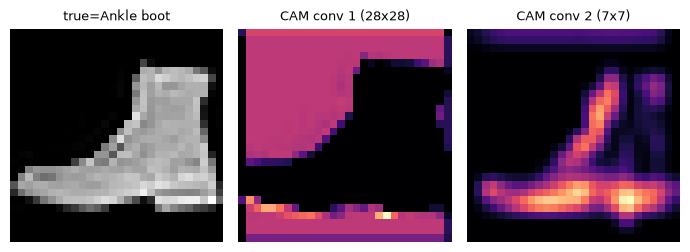

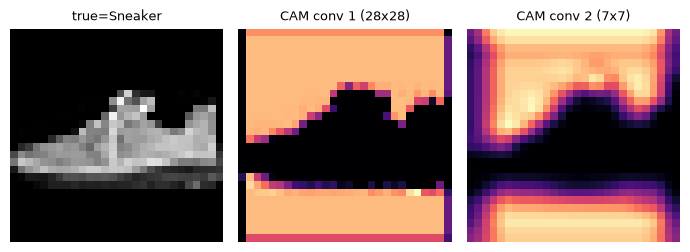

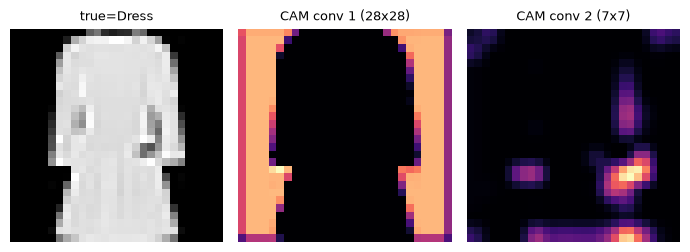

In [9]:
cam_first = GradCAM(cnn, cnn.net[0])  # conv แรก: 28x28, ก่อน pool
for i in ok_idx[:3]:
    heat1, _ = cam_first.cam(Xte_n[i:i + 1], class_idx=int(preds[i]))
    heat2, _ = cammer.cam(Xte_n[i:i + 1], class_idx=int(preds[i]))
    fig, axes = plt.subplots(1, 3, figsize=(7, 2.6))
    axes[0].imshow(X_test[i], cmap="gray")
    axes[0].set_title(f"true={CLASS_EN[y_test[i]]}", fontsize=9)
    axes[1].imshow(heat1, cmap="magma")
    axes[1].set_title("CAM conv 1 (28x28)", fontsize=9)
    axes[2].imshow(heat2, cmap="magma")
    axes[2].set_title("CAM conv 2 (7x7)", fontsize=9)
    for ax in axes:
        ax.set_axis_off()
    plt.tight_layout()
    plt.show()


**คำตอบข้อ 1:** CAM ชั้นแรก (28×28) **ละเอียดแต่ไม่ discriminative** — heatmap มักติดตามขอบ/พื้นผิวทั่วไปของวัตถุ และหน้าตาคล้ายกันไม่ว่าถาม class ไหน เพราะชั้นแรกเรียนรู้แค่ "ตัวกรองเบื้องต้น" (ขอบ, เส้น, จุด) ที่ยังไม่รู้ว่าโจทย์คืออะไร ส่วน CAM ชั้นสุดท้าย (7×7) **หยาบแต่โฟกัสสิ่งที่แยก class นั้นจริง** เพราะมันอยู่ถัดจากตัวตัดสิน (linear classifier) โดยตรง — gradient ของคะแนนจึงถ่วงน้ำหนักเฉพาะ feature ที่หนุน class นั้น นี่คือเหตุผลที่ Grad-CAM default ที่ "conv สุดท้าย": **trade-off ความละเอียด ↔ ความหมาย** ของ feature hierarchy


## ข้อ 2 — เฉลย: CAM ของภาพที่โมเดลผิด


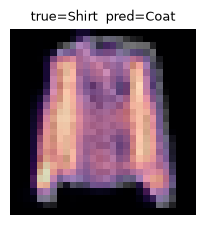

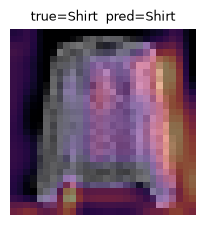

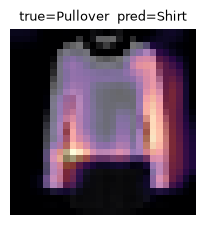

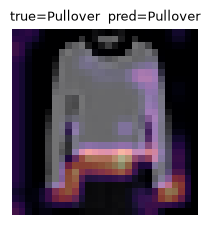

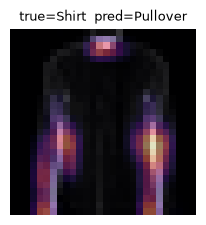

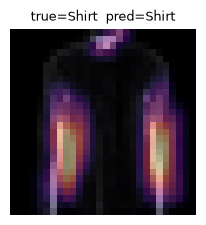

In [10]:
for i in wrong_idx[:3]:
    show_cam(i)  # CAM ของ class ที่โมเดลทำนาย (ผิด)
    show_cam(i, class_idx=int(y_test[i]))  # CAM ของ true class


**คำตอบข้อ 2:** ภาพผิดส่วนใหญ่ของโมเดลนี้เป็นคู่ใน "ตระกูลเดียวกัน" (Shirt ↔ T-shirt/Pullover/Coat, Sandal ↔ Sneaker) — จาก heatmap: **CAM ของ pred และ CAM ของ true มักทับบริเวณเดียวกัน** (ตัวเสื้อ/ทรงร่าง) แปลว่าโมเดล "มองถูกที่แต่ตีความผิด" — หลักฐานในภาพ 28×28 ขาวดำ (ความยาวแขน, จักรเย็บผ้า, ลายผ้า) เล็ก/เบลอเกินกว่าโมเดลจิ๋วจะแยกได้ ไม่ใช่มองพื้นหลังหลุด ถ้าคุณเจอภาพที่ CAM ชี้คนละที่สิ้นเชิง (เช่น CAM อยู่มุมภาพที่ว่าง) นั่นคือสัญญาณ shortcut learning — แยกออกและตรวจข้อมูลก่อน


## ข้อ 3 — เฉลย: class แย่สุด + คู่สับสนสูงสุด


In [11]:
from sklearn.metrics import confusion_matrix  # noqa: E402

cm = confusion_matrix(y_test, preds)
err_by_class = 1 - cm.diagonal() / cm.sum(1)
order = err_by_class.argsort()[::-1]
for i in order[:3]:
    n_err = int(cm[i].sum() - cm[i, i])
    print(f"{CLASS_EN[i]:<12} error {err_by_class[i]:.2%} ({n_err} ภาพ)")
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)
r, c = np.unravel_index(cm_off.argmax(), cm_off.shape)
print(f"คู่สับสนสูงสุด: true={CLASS_EN[r]} -> pred={CLASS_EN[c]} "
      f"({int(cm_off[r, c])} ภาพ)")


Shirt        error 39.81% (82 ภาพ)
Pullover     error 21.31% (39 ภาพ)
T-shirt      error 20.51% (40 ภาพ)
คู่สับสนสูงสุด: true=Shirt -> pred=Coat (28 ภาพ)


**คำตอบข้อ 3:** (จากรอบรันของเรา) **Shirt แย่สุด** (error 39.8% — 82 ภาพ) — สมเหตุสมผลเพราะ Shirt "อยู่กลาง" ตระกูลเสื้อ (คล้าย T-shirt, Pullover, Coat พร้อมกัน) และ**คู่สับสนสูงสุดคือ true=Shirt → pred=Coat (28 ภาพ)** — ยังอยู่ในตระกูลเสื้อทั้งคู่ ทรงและความยาวแขนเหมือนกันในภาพขาวดำ 28×28 แม้คนก็แยกยาก (รอบของคุณอาจให้คู่เพื่อนบ้านเช่น T-shirt ↔ Shirt — ให้ตอบจากผลจริงของคุณ) ทางแก้ที่ตรงจุด: ข้อมูล/ความละเอียดเพิ่ม, augmentation, หรือออกแบบขั้นตรวจมนุษย์เฉพาะคู่นี้ — ไม่ใช่เทรนนานขึ้น


## ข้อ 4 — เฉลย: ตาราง metric ของคุณเอง


In [12]:
import pandas as pd  # noqa: E402

my_table = pd.DataFrame([
    {"modality": "ภาพ", "module": "M1", "metric": "accuracy (สูงยิ่งดี)",
     "ค่าตัวอย่าง": round(acc_cnn, 3), "ที่มา": "รันสดใน notebook นี้"},
    {"modality": "OCR", "module": "M2", "metric": "CER (ต่ำยิ่งดี)",
     "ค่าตัวอย่าง": 0.174,
     "ที่มา": "ค่าตัวอย่างจาก output ที่บันทึกไว้ของ M2 (thai-trocr)"},
    {"modality": "เสียง", "module": "M5", "metric": "WER (ต่ำยิ่งดี)",
     "ค่าตัวอย่าง": 0.25,
     "ที่มา": "ค่าตัวอย่างเชิงประกอบ — เติมค่าจากการรัน M5 จริงของคุณ"},
])
print(my_table.to_string(index=False))
print("\nerror rate ร่วม: ภาพ "
      f"{1 - acc_cnn:.3f} / OCR 0.174 / เสียง 0.25 (สมมุติ)")


modality module               metric  ค่าตัวอย่าง                                                  ที่มา
     ภาพ     M1 accuracy (สูงยิ่งดี)        0.875                                   รันสดใน notebook นี้
     OCR     M2      CER (ต่ำยิ่งดี)        0.174  ค่าตัวอย่างจาก output ที่บันทึกไว้ของ M2 (thai-trocr)
   เสียง     M5      WER (ต่ำยิ่งดี)        0.250 ค่าตัวอย่างเชิงประกอบ — เติมค่าจากการรัน M5 จริงของคุณ

error rate ร่วม: ภาพ 0.125 / OCR 0.174 / เสียง 0.25 (สมมุติ)


**คำตอบข้อ 4:** ตารางของเรา: accuracy ~0.87 (รันสด), CER 0.174 (ตัวอย่างจาก M2), WER 0.25 (สมมุติ) — วัดใน**หน่วยของตัวเอง**: OCR ผิด ~17% ของอักขระคือ "แย่มาก" ถ้าผลที่ต้องการคือตัวเลขค่าการวัด (ตัวเลขผิด 1 ตัว = ค่าผิดทั้งจุด) ขณะที่ภาพผิด 13% ต่อ "ทั้งภาพ" อาจยอมรับได้ในงานคัดกรองที่มีคนตรวจซ้ำ จุดสำคัญ: **เทียบข้าม modality ตรง ๆ ไม่ได้** — หน่วยความผิด (ภาพ/อักขระ/คำ), dataset, โมเดล และ "ราคาของความผิด" ต่างกันทั้งหมด ที่เทียบได้คือระดับความยากโดยประมาณบนสเกล 0–1 และ**รูปแบบของ error** (คู่สับสน / อักขระสระ-วรรณยุกต์ / คำพ้องเสียง) ไม่ใช่ตัวเลขดิบ


## ข้อ 5 — เฉลย: แผนตรวจสอบ 3 ขั้น

**คำตอบ (ตัวอย่างที่ยุติธรรม):**

1. **วัด (ตาราง metric + confusion matrix)** — รายงาน accuracy/error rate บน test set ที่โมเดลไม่เคยเห็น **แยกต่อ class** และระบุคู่สับสนสูงสุด — ตอบคำถาม "ผิดเท่าไร ผิดแบบไหน" ผลลัพธ์: ตาราง + ตัวเลขที่อ้างอิงได้ (ไม่ใช่ความรู้สึก)
2. **ดู (error inspection 4 ขั้น + Grad-CAM)** — รวบรวม error ทั้งหมด จัดกลุ่มตามคู่สับสน/ประเภทชิ้นงาน แล้วส่อง CAM ของตัวอย่างผิด ว่าโมเดลมองจุดที่สมเหตุสมผลไหม (จับ shortcut เช่น ไปมองพื้นหลัง/แสงเงา) — ตอบคำถาม "ทำไมผิด และโมเดลใช้หลักฐานถูกต้องไหม" ผลลัพธ์: ภาพตัวอย่าง + CAM + สมมติฐานที่เขียนเป็นข้อ ๆ
3. **ตัดสิน (ขอบเขตการใช้)** — สรุปว่า class/เงื่อนไขไหน "เชื่อได้" (error ต่ำ + CAM สมเหตุสมผล) คู่ไหนต้อง**มนุษย์ตรวจซ้ำทุกครั้ง** (คู่สับสนสูงสุด) และตัวอย่าง error เหล่านี้กลายเป็นข้อมูลเก็บสำหรับปรับปรุงรอบถัดไป — ตอบคำถาม "เชื่อได้แค่ไหน ใช้ตรงไหนได้บ้าง" ผลลัพธ์: รายการข้อจำกัดที่เขียนส่งต่อได้

**ประเด็นปิด:** Grad-CAM ทำให้โมเดล "ให้เหตุผลได้" แต่ไม่ใช่หลักฐานเชิงสาเหตุ — ใช้เป็นเครื่องมือตรวจสอบ (audit) คู่กับตัวเลข ไม่ใช่ทดแทนกัน
